In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_catboost_tuning, run_lgbm_tuning, run_lr_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Car](https://www.openml.org/search?type=data&id=40975&sort=runs&status=active)

In [2]:
dataset_id = 40975
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr, multi=True)

[I 2025-04-21 17:23:25,438] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-21 17:23:25,455] Trial 0 finished with value: 0.9648425908698476 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 0 with value: 0.9648425908698476.
[I 2025-04-21 17:23:25,468] Trial 1 finished with value: 0.9803819395219184 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 1 with value: 0.9803819395219184.
[I 2025-04-21 17:23:25,481] Trial 2 finished with value: 0.9648425908698476 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 1 with value: 0.9803819395219184.
[I 2025-04-21 17:23:25,508] Trial 3 finished with value: 0.9960149796728948 and parameters: {'penalty': 'l2', 'C': 10}. Best is trial 3 with value: 0.9960149796728948.
[I 2025-04-21 17:23:25,525] Trial 4 finished with value: 0.9918067659464861 and parameters: {'penalty': 'l2', 'C': 1}. Best is trial 3 with value: 0.9960149796728948.
[I 2025-04-21 17:23:25,574] Trial 5 finished with 

In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb, multi=True)

[I 2025-04-21 17:23:29,507] A new study created in memory with name: catboost_optimization
[I 2025-04-21 17:23:30,061] Trial 0 finished with value: 0.9958825943391751 and parameters: {'depth': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9958825943391751.
[I 2025-04-21 17:23:30,998] Trial 1 finished with value: 1.0 and parameters: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 0.01}. Best is trial 1 with value: 1.0.
[I 2025-04-21 17:23:31,435] Trial 2 finished with value: 0.9997372878139499 and parameters: {'depth': 2, 'learning_rate': 0.1, 'l2_leaf_reg': 0.1}. Best is trial 1 with value: 1.0.
[I 2025-04-21 17:23:33,906] Trial 3 finished with value: 0.9854203462661988 and parameters: {'depth': 6, 'learning_rate': 0.001, 'l2_leaf_reg': 0.001}. Best is trial 1 with value: 1.0.
[I 2025-04-21 17:23:36,564] Trial 4 finished with value: 1.0 and parameters: {'depth': 6, 'learning_rate': 0.3, 'l2_leaf_reg': 0.01}. Best is trial 1 with value: 1.0.
[I 2025-04-2

In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm, multi=True)

[I 2025-04-21 17:25:17,916] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 17:25:19,957] Trial 0 finished with value: 0.9999124292713166 and parameters: {'num_leaves': 32, 'reg_alpha': 0.0001, 'reg_lambda': 10.0, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9999124292713166.
[I 2025-04-21 17:25:20,873] Trial 1 finished with value: 0.9775437570454951 and parameters: {'num_leaves': 16, 'reg_alpha': 10.0, 'reg_lambda': 1e-07, 'learning_rate': 0.01}. Best is trial 0 with value: 0.9999124292713166.
[I 2025-04-21 17:25:22,963] Trial 2 finished with value: 0.9993229576845588 and parameters: {'num_leaves': 8, 'reg_alpha': 0.1, 'reg_lambda': 0.001, 'learning_rate': 0.01}. Best is trial 0 with value: 0.9999124292713166.
[I 2025-04-21 17:25:23,616] Trial 3 finished with value: 0.996078755039714 and parameters: {'num_leaves': 2, 'reg_alpha': 1e-05, 'reg_lambda': 0.1, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9999124292713166.
[I 2025-04-21 17:25:26,

In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


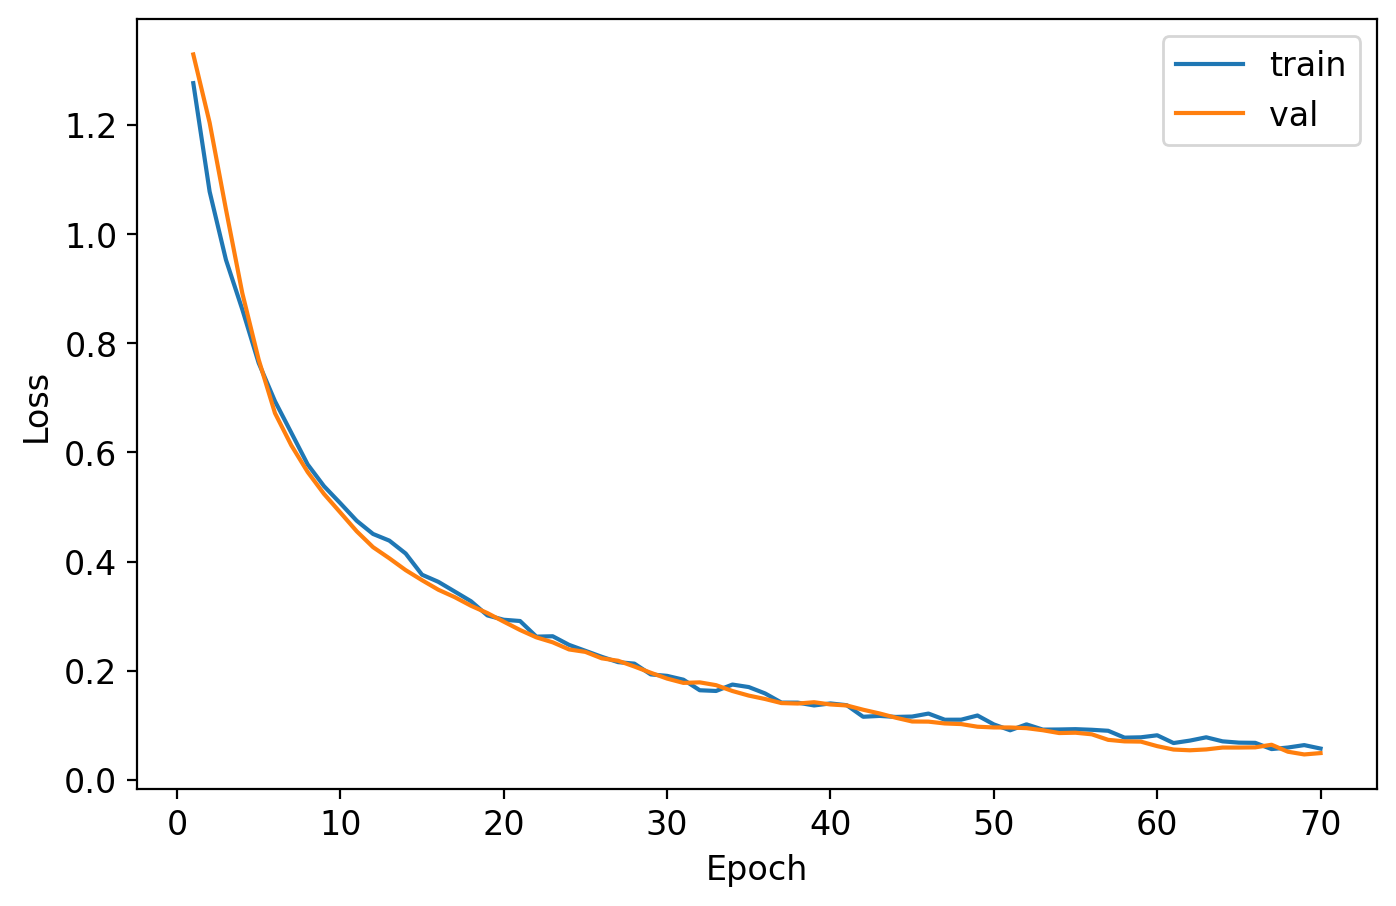

Epoch 70: train loss = 0.0575; valid loss = 0.0492


In [11]:
net = TABMLP(len(numerical_features), emb_dims, num_classes=len(np.unique(y_train))).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 70, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device, multi=True)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob, multi=True)

In [13]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.9914±0.0032,0.8674±0.0489,0.9244±0.0194,0.8783±0.0556,0.8733±0.0488
1,CatBoost,1.0000±0.0000,1.0000±0.0000,1.0000±0.0000,1.0000±0.0000,1.0000±0.0000
2,LightGBM,1.0000±0.0000,1.0000±0.0000,1.0000±0.0000,1.0000±0.0000,1.0000±0.0000
3,TABMLP,0.9990±0.0010,0.9870±0.0076,0.9827±0.0101,0.9851±0.0094,0.9893±0.0071
